In [14]:
import matplotlib.pyplot as plt
import numpy as np
from marks import marks
import multiprocessing as mp
import os
from datetime import datetime
import threading
from tqdm import tqdm
import threading
from dwave.system import DWaveSampler, EmbeddingComposite
from collections import defaultdict
import params as pm
import networkx as nx
import minorminer
import time
import string
import dwave.inspector

In [15]:
marks_to_consider = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
M = len(marks_to_consider)
N = 25
L = 5
beta = 0.8
n_samples = 100
#n_steps = 3_000

#params = {
#    'h': np.ones(M) * 4,
#    'J': np.ma.masked_array(
#        data=-np.load('paper_J.npy')[:M, :M],
#        mask=np.triu(np.ones((M, M)), k=0)
#    ),
#    'K': -np.load('paper_K.npy')[:M, :L]
#}
params = pm.load('live_params2.npy')

stats_exp = load_exp_stats(marks_to_consider, L, suffix='_bdt3')

In [4]:
#Q = defaultdict(int)
#
## independent propensity
#for n in range(N):
#    for m in range(M):
#        x = n * M + m
#        Q[(x, x)] = params['h'][m]
#
## intra-nucleosome correlation
#for n in range(N):
#    for m in range(M):
#        for k in range(m):
#            x = n * M + m
#            y = n * M + k
#            Q[(x, y)] = params['J'][m, k]
#            
## inter-nucleosome correlation
#for n in range(N):
#    for m in range(M):
#        for l in range(1, np.minimum(L+1, N)):
#            x = n * M + m
#            y = ((n+l)%N) * M + m
#            if x < y:
#                Q[(x, y)] = params['K'][m, l-1]
#            else:
#                Q[(y, x)] = params['K'][m, l-1]

In [33]:
h_ = params['h'] / 2
for m in range(params['h'].shape[0]):
    h_[m] += (np.sum(np.ma.compressed(params['J'][m, :])) + np.sum(np.ma.compressed(params['J'][:, m]))) / 4
J_ = params['J'] / 4
K_ = params['K'] / 4

h = defaultdict(int)
# independent propensity
#for n in range(N):
#    for m in range(M):
#        x = n * M + m
#        h[x] = h_[m]
#
J = defaultdict(int)
# intra-nucleosome correlation
for n in range(N):
    for m in range(M):
        for k in range(m):
            x = n * M + m
            y = n * M + k
            J[(x, y)] = J_[m, k]

# inter-nucleosome correlation
for n in range(N):
    for m in range(M):
        for l in range(1, 6):
            x = n * M + m
            y = ((n+l)%N) * M + m
            if x < y:
                J[(x, y)] = K_[m, l-1]
            else:
                J[(y, x)] = K_[m, l-1]

In [34]:
#sampler = DWaveSampler(solver='Advantage_system6.1')
#_, T, _ = sampler.structure
#G = nx.Graph()
#for x in Q:
#    if x[0] != x[1]:
#        G.add_edge(x[0], x[1])
#embedding = minorminer.find_embedding(G, T)
sampler = EmbeddingComposite(DWaveSampler(solver='Advantage_system6.1'))
#sampler = DWaveSampler(solver='Advantage_system6.1')

In [ ]:
#for at in [1, 2, 3, 4, 5, 6, 7, 8, 9]:
#    response = sampler.sample_qubo(Q, annealing_time=at, num_reads=n_samples, chain_strength=2, return_embedding=True)#, embedding=embedding)
#    states = []
#    for r in response.data():
#        for _ in range(r.num_occurrences):
#            states.append(np.array(list(r.sample.values())).reshape(N, M).T)
#    #print(at, len(states))
#    np.save(f'samples/at{at}_states.npy', states)
#    breaks = [d.chain_break_fraction for d in response.data()]
#    print(at, np.mean(breaks))

In [40]:
#response = sampler.sample_qubo(Q, annealing_time=20, num_reads=n_samples, chain_strength=2)
response = sampler.sample_ising(h, J, annealing_time=3, num_reads=n_samples, chain_strength=10)
states = []
for r in response.data():
    for _ in range(r.num_occurrences):
        states.append(np.array(list(r.sample.values())).reshape(N, M).T)
print('Number of states', len(states))

Number of states 100


In [ ]:
breaks = [d.chain_break_fraction for d in response.data()]
print(np.mean(breaks))

In [ ]:
states = []
energies = []
for r in response.data():
    #print(np.array(list(r.sample.values())).reshape(N, M).T, np.round(r.energy, 3))
    states.append(np.array(list(r.sample.values())).reshape(N, M).T)
    energies.append(r.energy)
t = time.time()
np.save(f'samples/{t}_states.npy', states)
np.save(f'samples/{t}_energies.npy', energies)
np.save(f'beautiful_states_qas_big.npy', states)

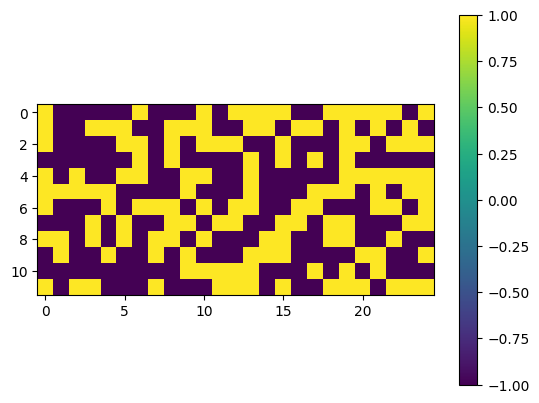

In [41]:
#states = [initialize_state_random(M, N, p=stats_exp['means']) for _ in range(n_samples)]
#states = [do_mmc_iteration(state, params, beta, n_steps) for state in states]

plt.figure()
plt.imshow(states[-1])
plt.colorbar()
plt.show()

stats_sim = get_stats_for_states(states, L)
#update_via_lr(params, stats_sim, stats_exp, lr)
#update_via_lr_and_momentum(params, stats_sim, stats_exp, velocity, lr, momentum)

error, e_parts = get_relative_error(stats_sim, stats_exp)

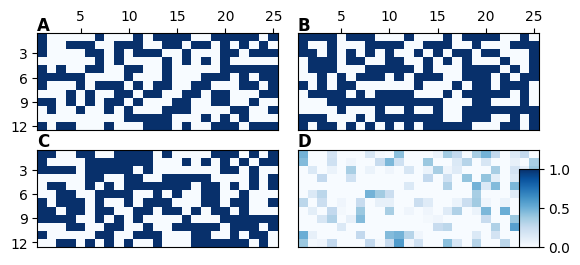

In [42]:
cm = 1 / 2.54
fig, ax = plt.subplots(2, 2, figsize=(15*cm, 7*cm))
ax[0, 0].imshow(states[-1], cmap='Blues', aspect='auto')
ax[0, 1].imshow(states[-2], cmap='Blues', aspect='auto')
ax[1, 0].imshow(states[-3], cmap='Blues', aspect='auto')
im = ax[1, 1].imshow(np.mean(states, axis=0), cmap='Blues', aspect='auto', vmin=0, vmax=1)
for i in range(2):
    ax[1, i].set_xticks([])
    ax[0, i].set_xticks(range(4, 25, 5), range(5, 26, 5))
    ax[0, i].xaxis.tick_top()
    ax[i, 1].set_yticks([])
    ax[i, 0].set_yticks(range(2, 12, 3), range(3, 13, 3))
fig.colorbar(im, ax=ax[1, 1], pad=-0.15, aspect=4, anchor=(1, 0), shrink=0.8)
plt.tight_layout()
for n, a in enumerate(ax.flatten()):
    a.text(0, 1.03, string.ascii_uppercase[n], transform=a.transAxes, 
            size=12, weight='bold')
plt.savefig('free_samples.pdf')

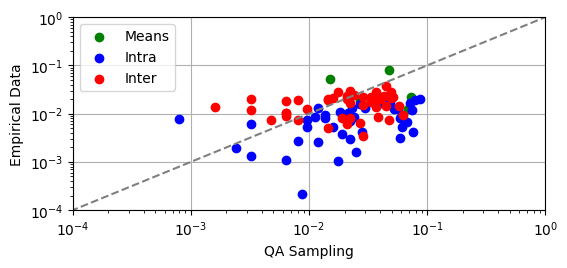

In [43]:
cm = 1 / 2.54
plt.figure(figsize=(15*cm, 7*cm))
plt.scatter(stats_sim['means'].flatten(), stats_exp['means'].flatten(), color='green', label='Means')
plt.scatter(np.ma.compressed(stats_sim['intra_corr']), np.ma.compressed(stats_exp['intra_corr']), color='blue', label='Intra')
plt.scatter(stats_sim['inter_corr'].flatten(), stats_exp['inter_corr'].flatten(), color='red', label='Inter')
plt.plot([0, 1], [0, 1], color='gray', ls='--')
plt.xlabel('QA Sampling')
plt.ylabel('Empirical Data')
plt.grid()
plt.gca().set_axisbelow(True)
plt.xscale('log')
plt.yscale('log')
plt.xlim([1e-4, 1e0])
plt.ylim([1e-4, 1e0])
plt.legend()
plt.subplots_adjust(left=0.15, right=0.95, top=0.9, bottom=0.2)
plt.savefig('stats_qa.pdf')

In [ ]:
all_sim = np.concatenate([stats_sim['means'].flatten(), np.ma.compressed(stats_sim['intra_corr']), stats_sim['inter_corr'].flatten()])
all_exp = np.concatenate([stats_exp['means'].flatten(), np.ma.compressed(stats_exp['intra_corr']), stats_exp['inter_corr'].flatten()])
all_sim[all_sim==0] = 0.0001
print(np.corrcoef(all_sim, all_exp)[0, 1])
print(np.corrcoef(np.log(all_sim), np.log(all_exp))[0, 1])

In [ ]:
all_sim_log = np.log(all_sim)
all_exp_log = np.log(all_exp)
SS_res = np.sum(np.square(all_exp_log - all_sim_log))
SS_tot = np.sum(np.square(all_exp_log - np.mean(all_exp_log)))
R_squared = 1 - SS_res / SS_tot
print(R_squared)

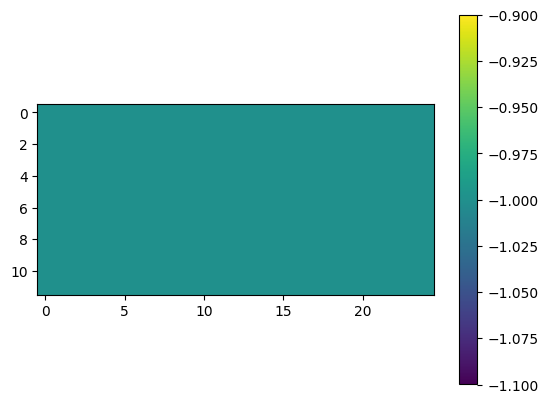

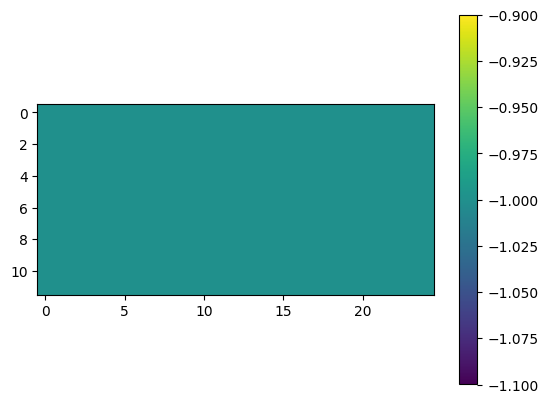

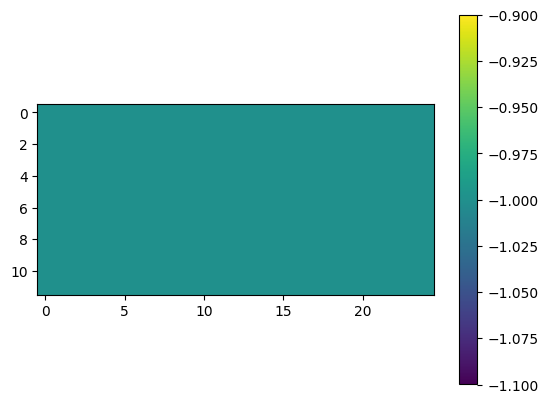

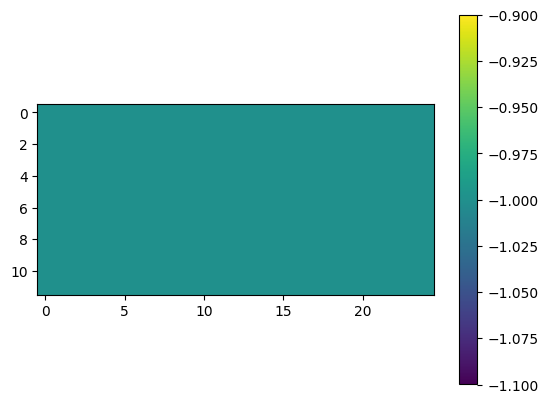

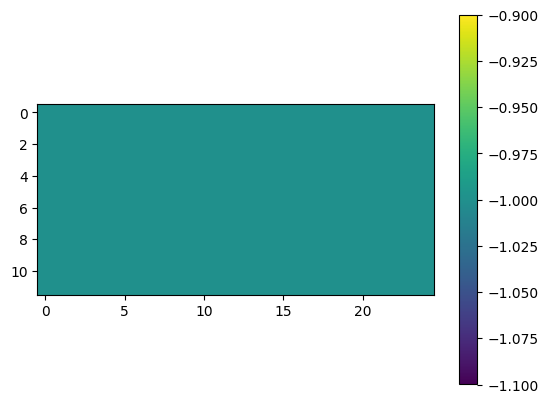

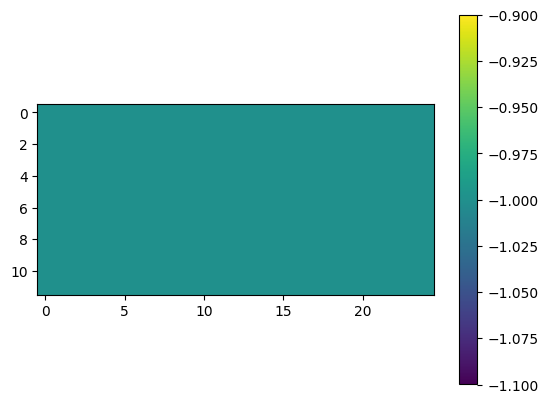

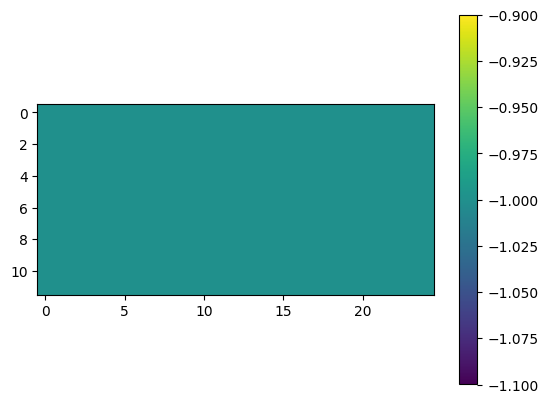

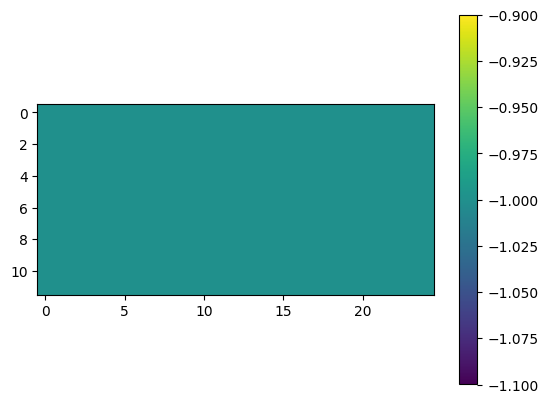

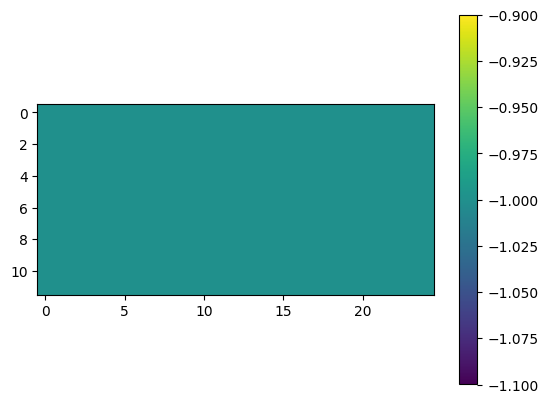

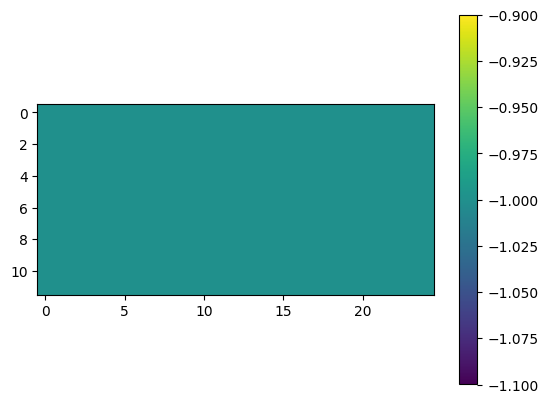

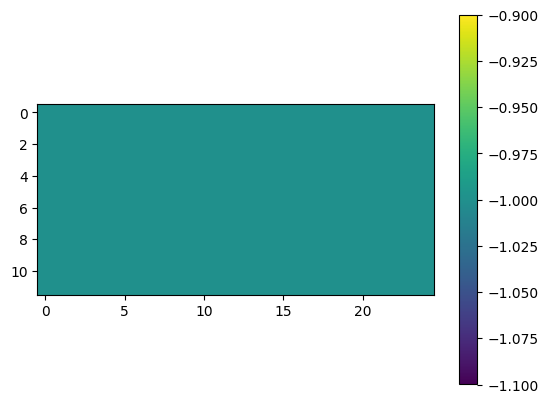

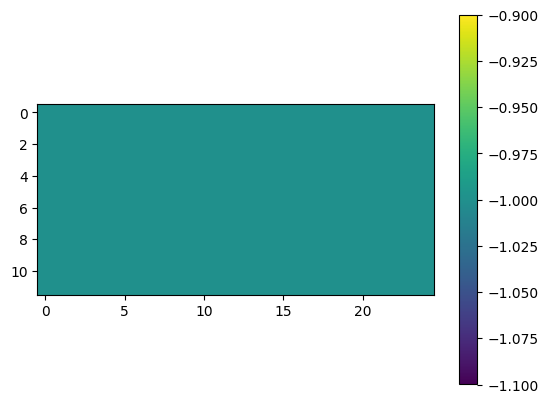

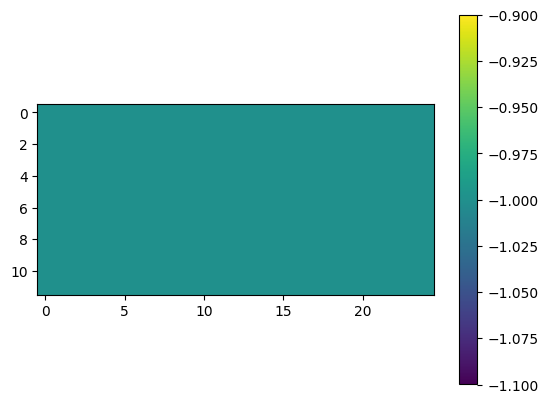

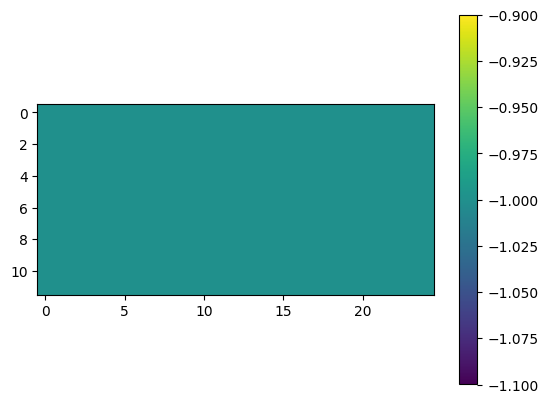

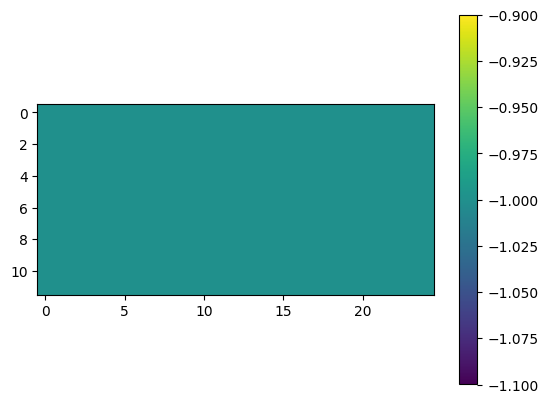

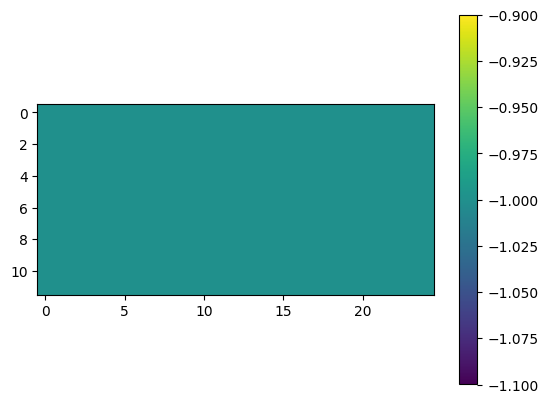

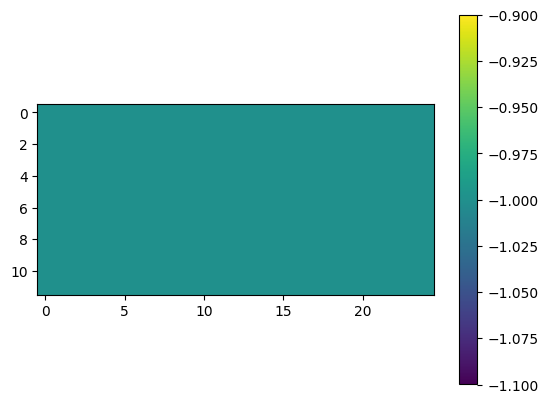

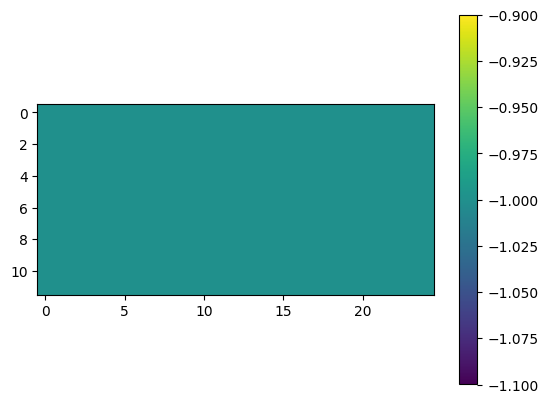

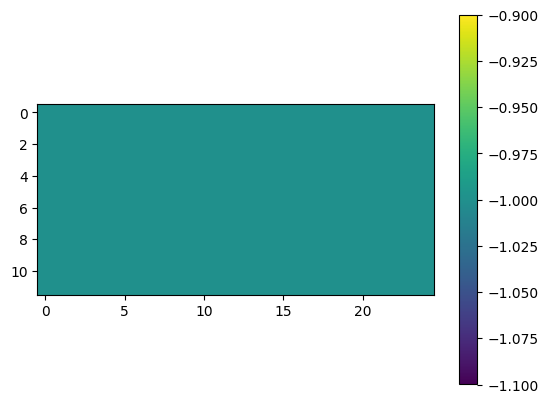

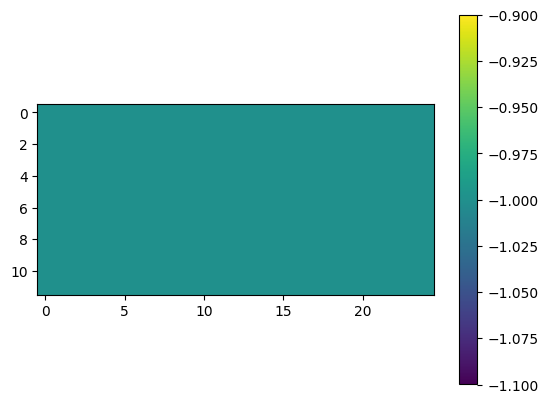

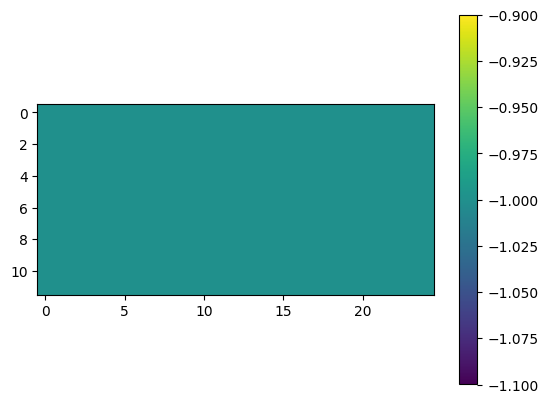

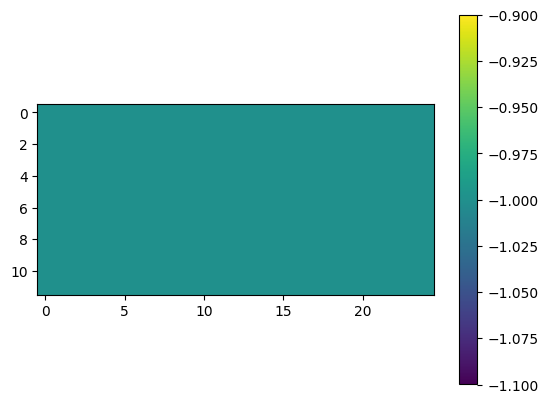

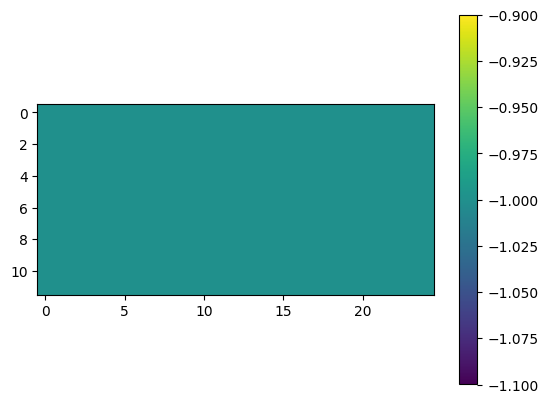

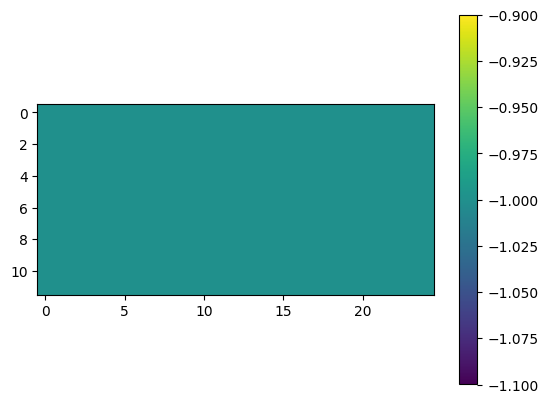

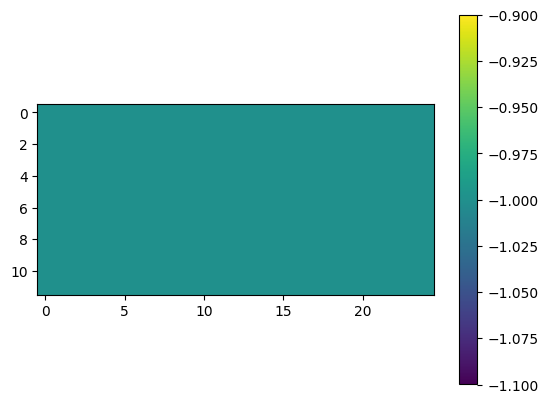

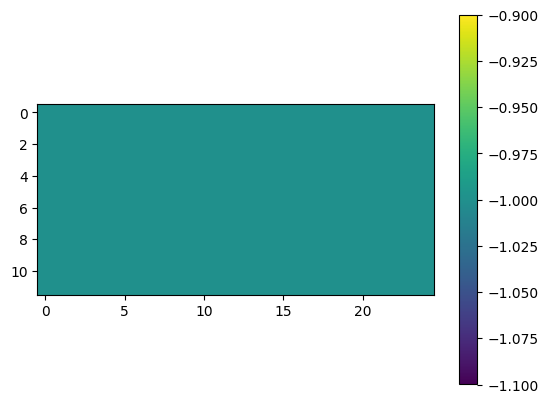

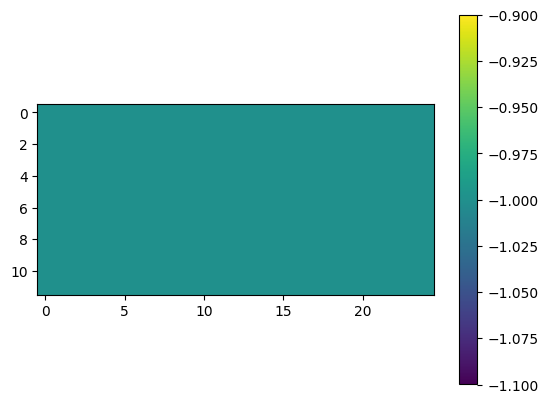

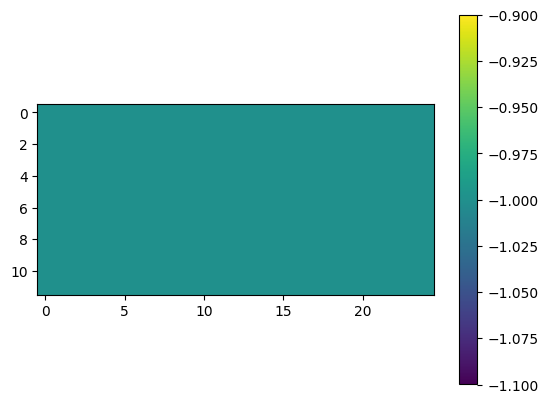

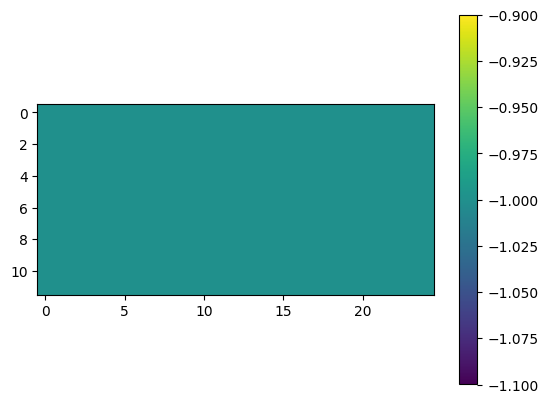

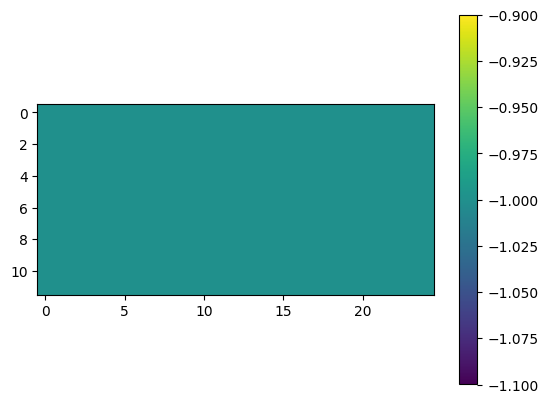

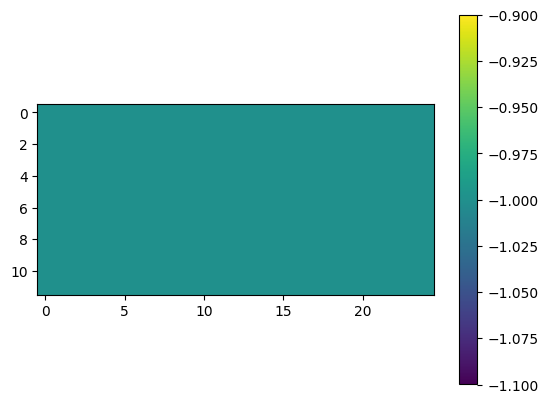

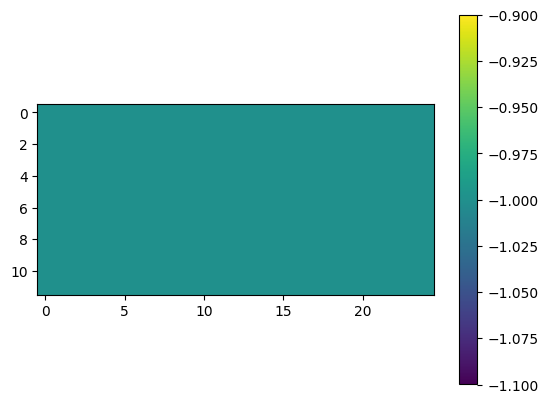

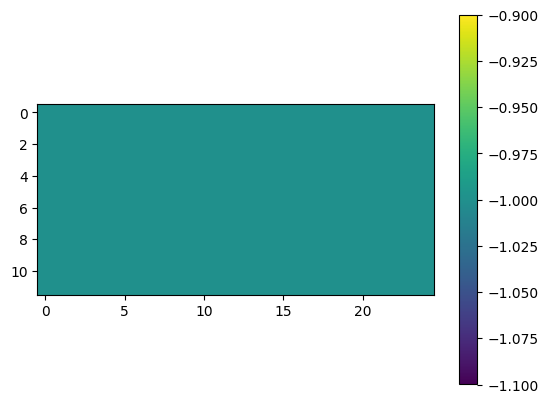

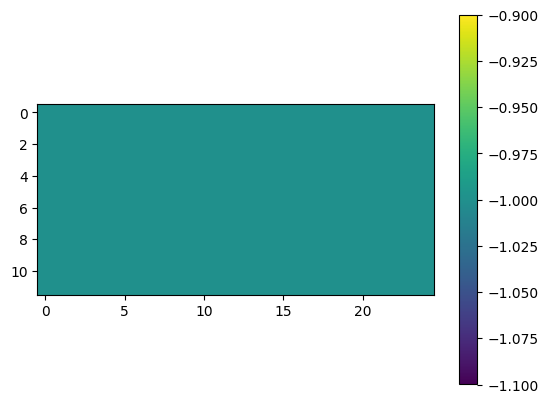

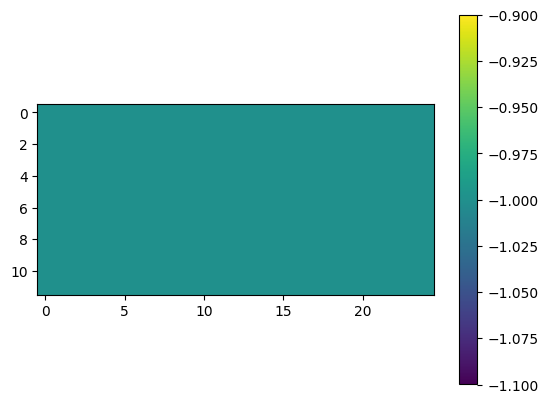

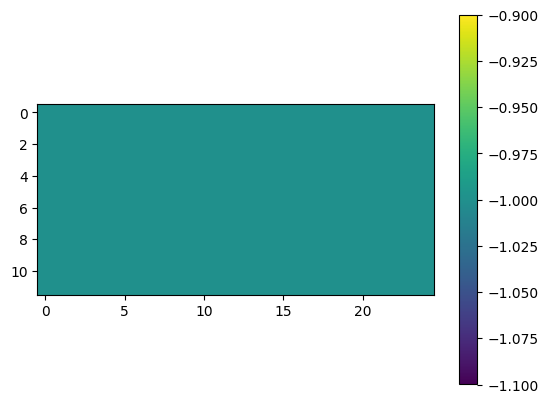

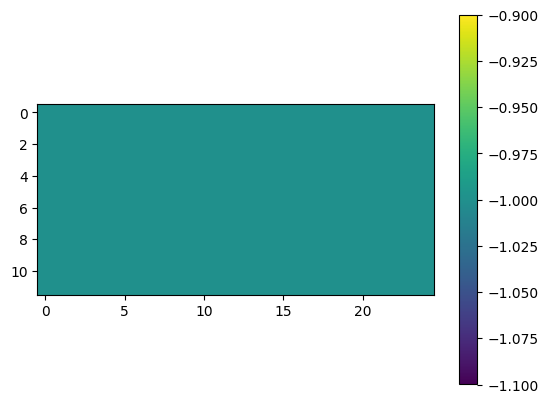

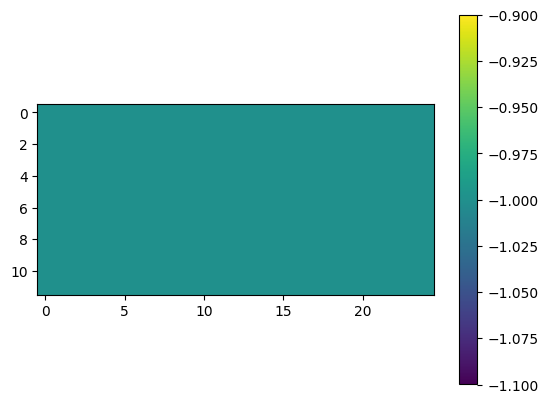

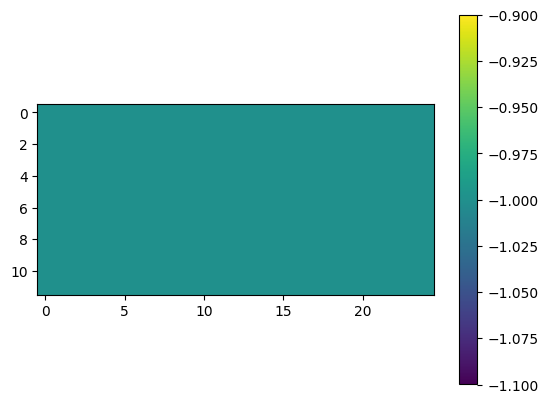

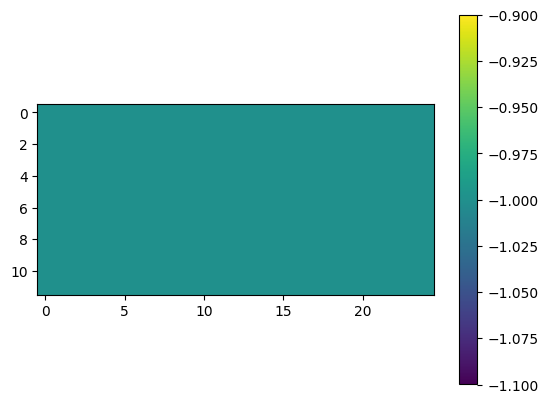

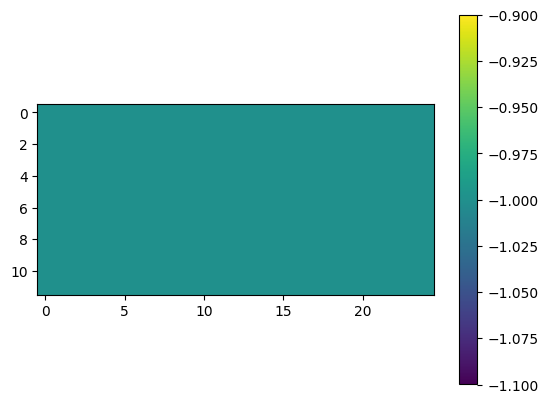

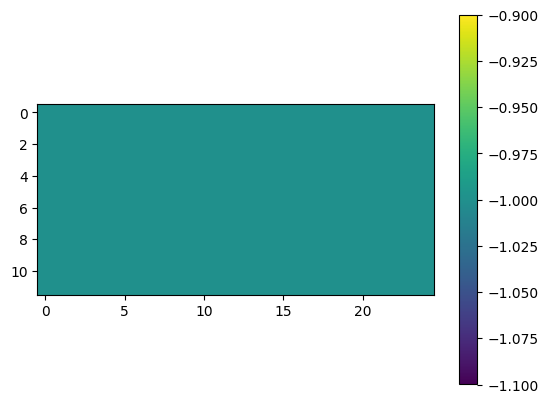

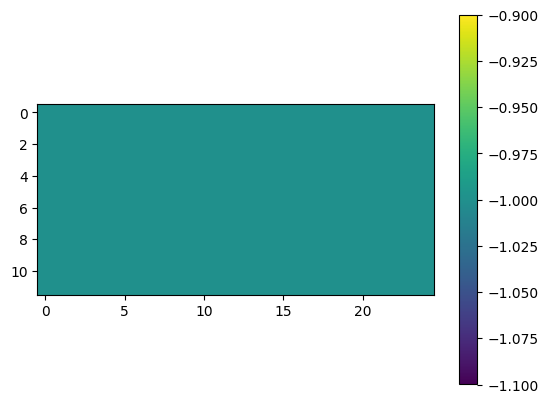

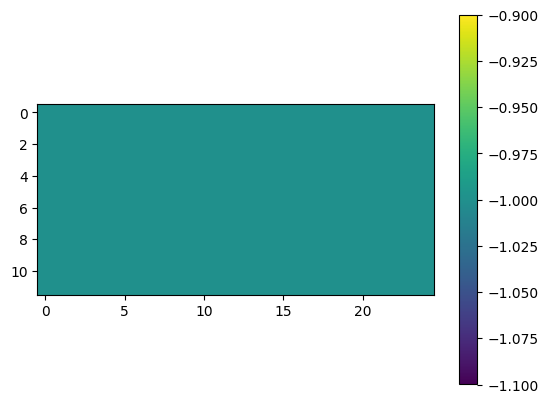

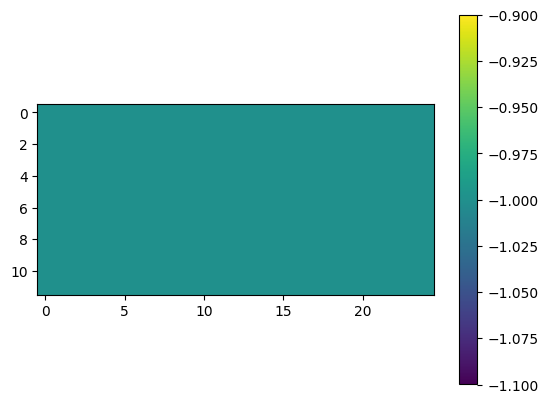

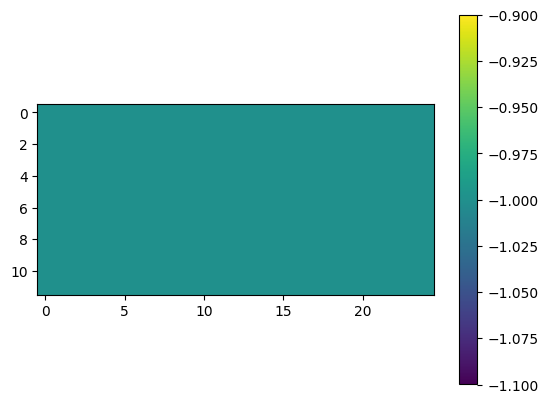

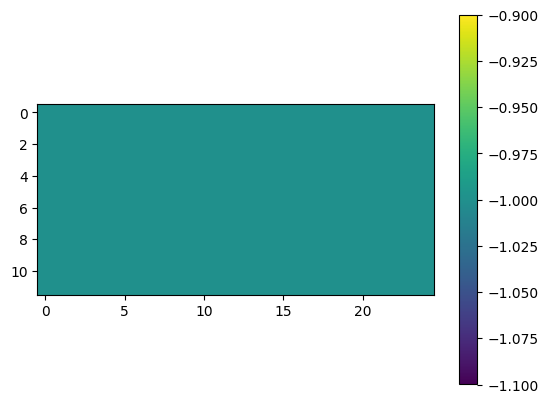

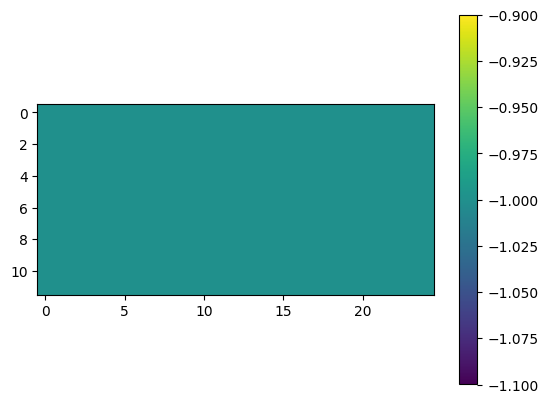

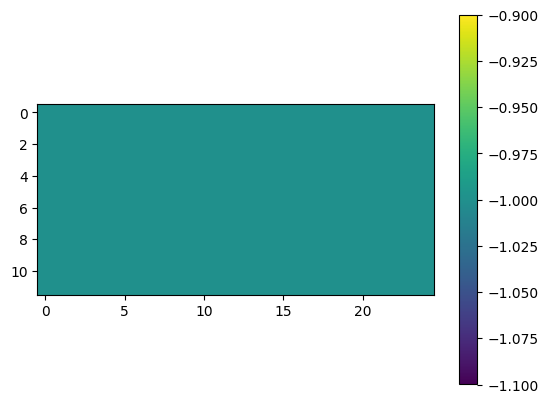

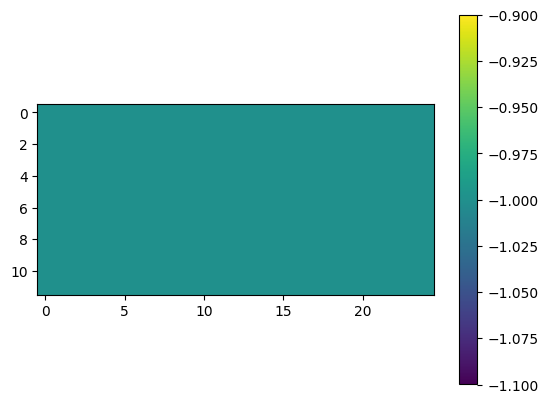

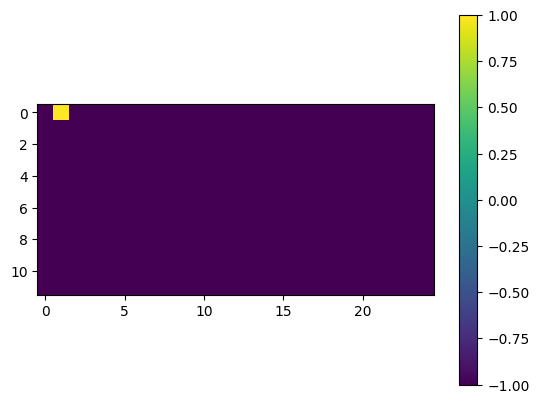

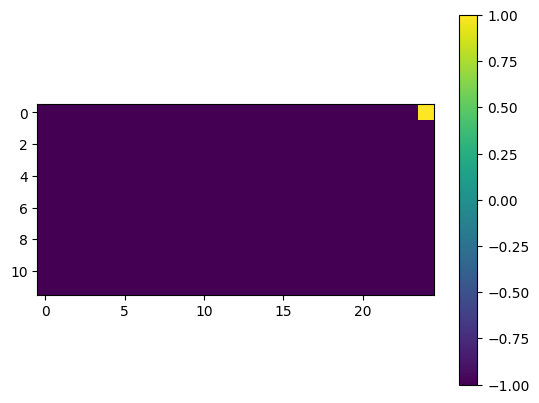

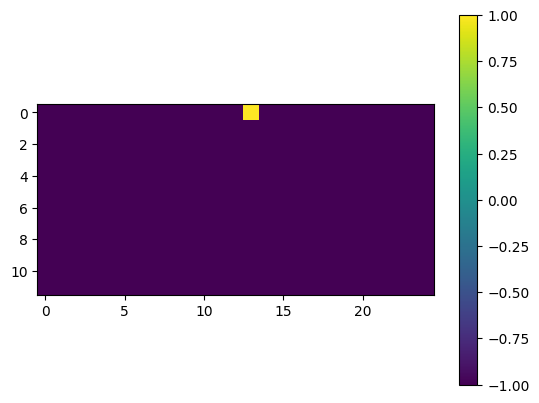

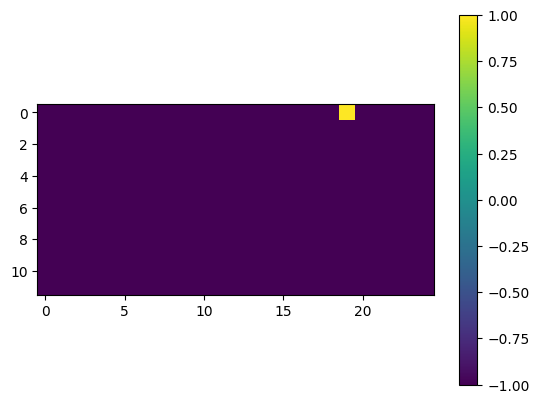

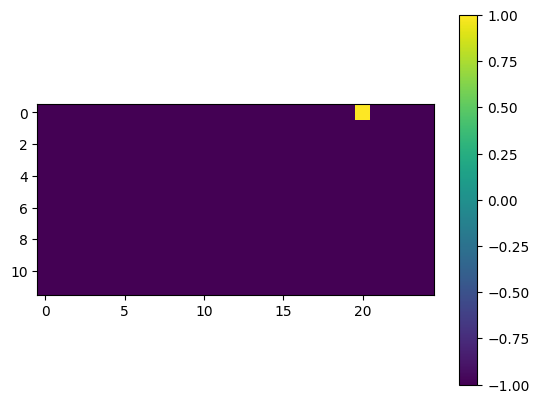

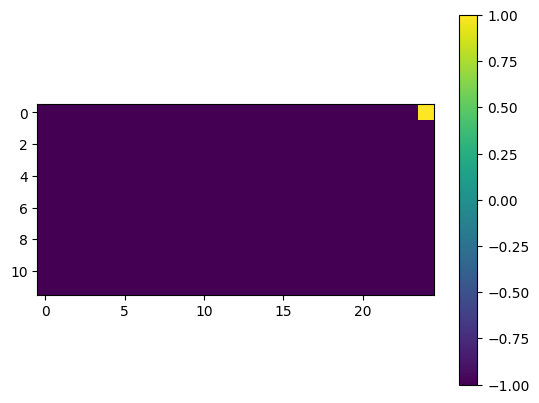

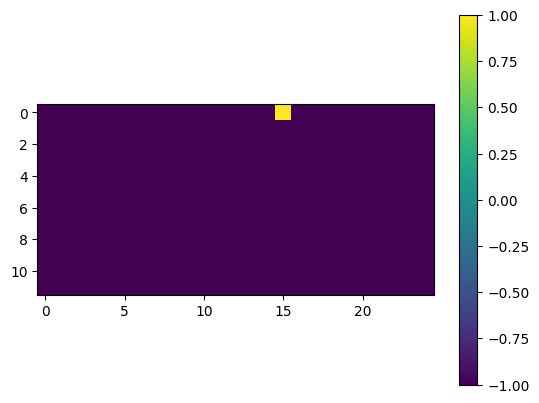

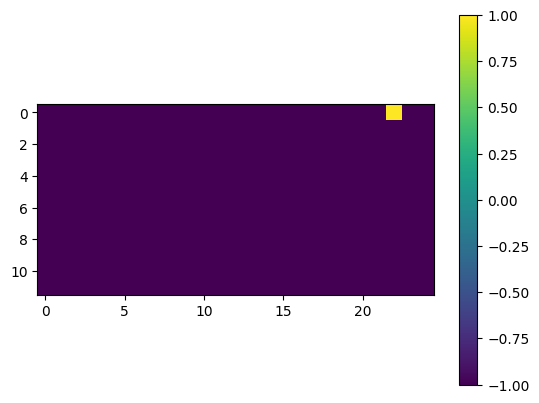

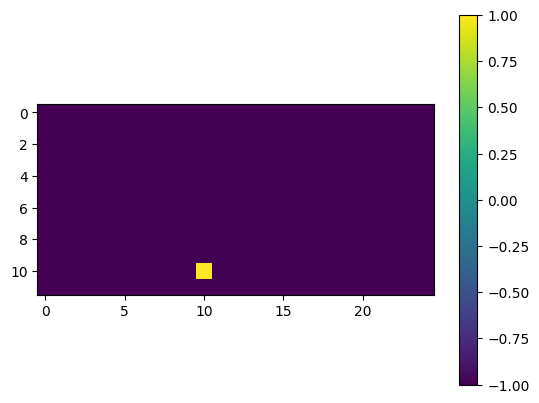

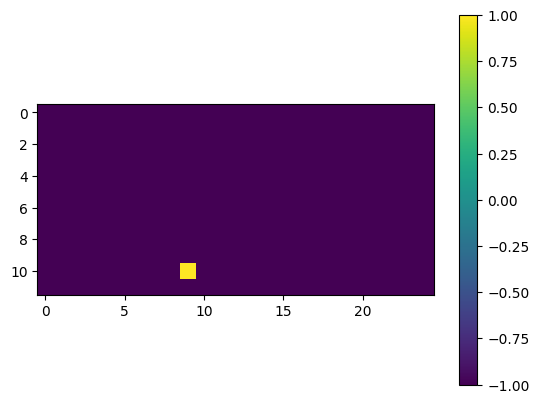

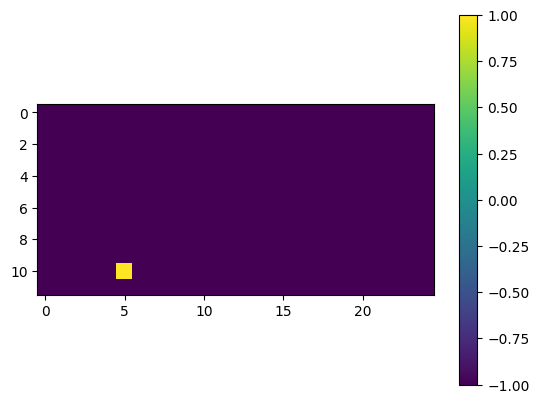

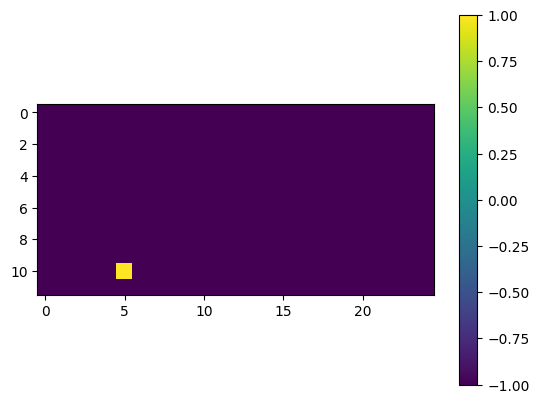

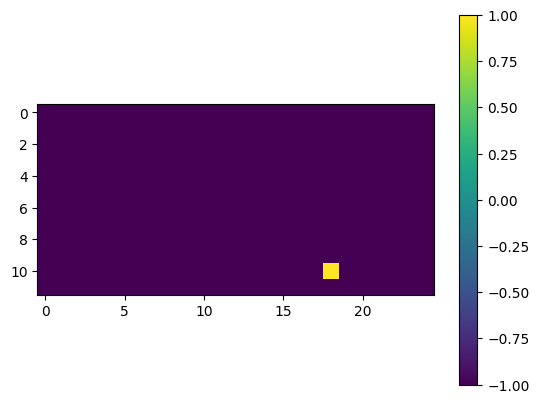

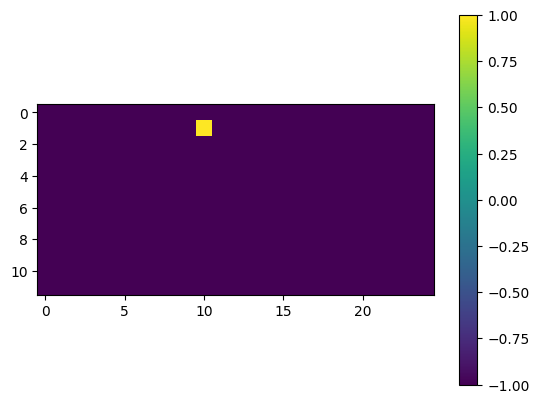

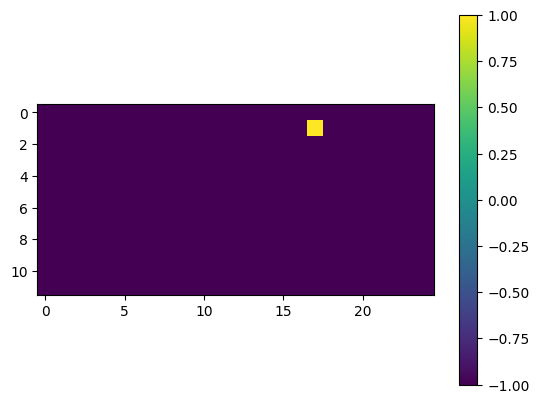

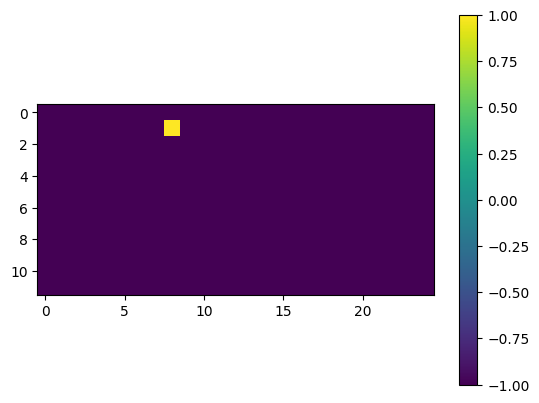

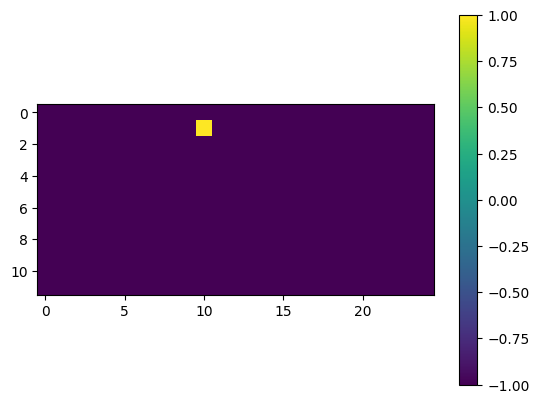

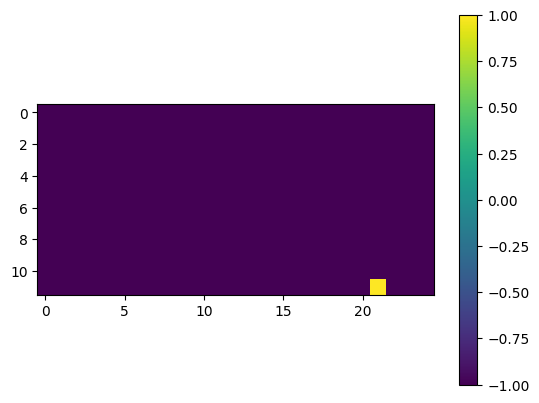

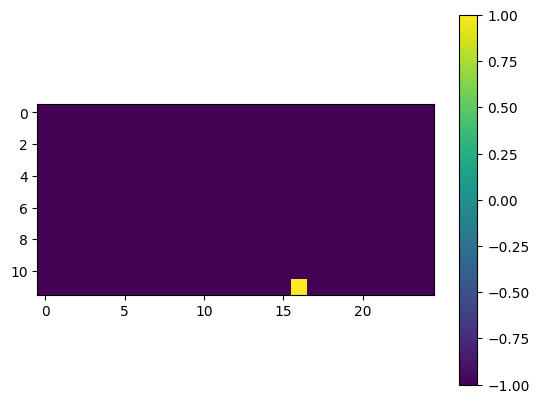

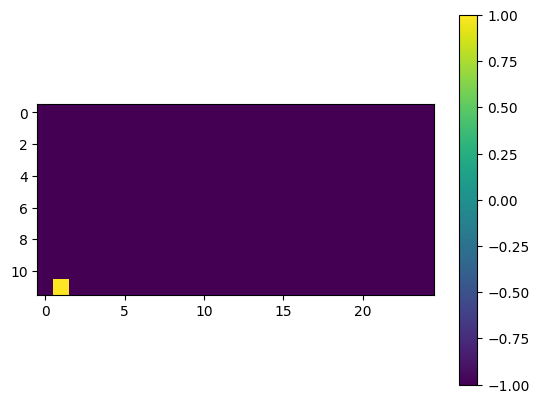

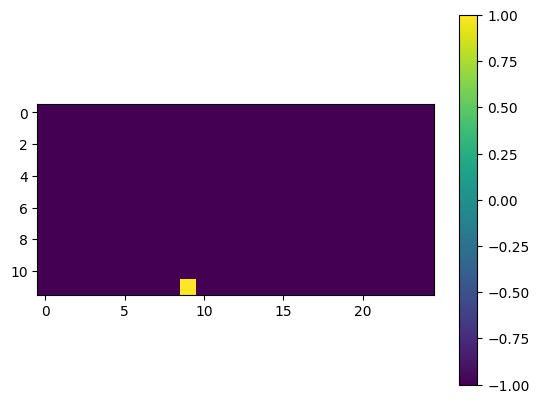

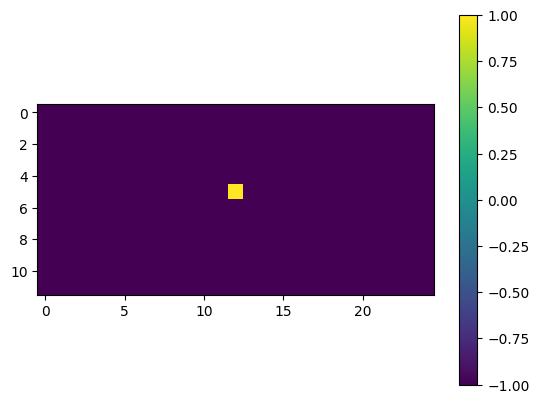

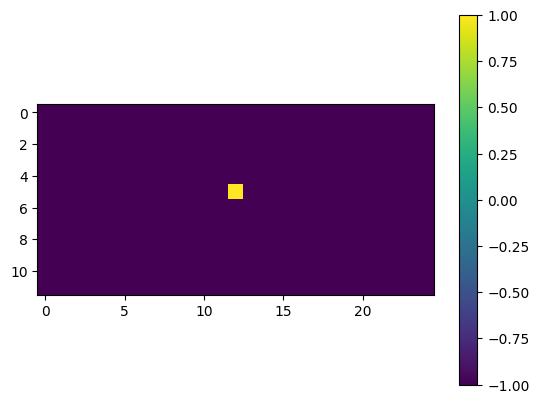

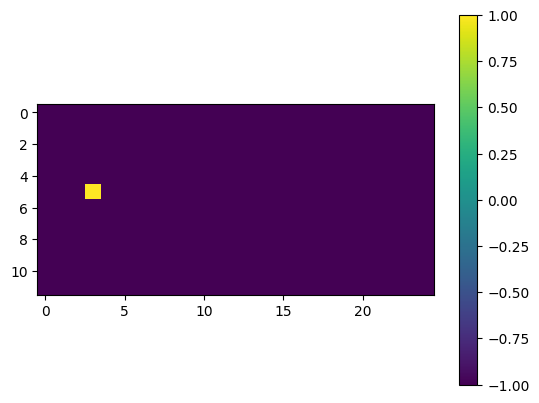

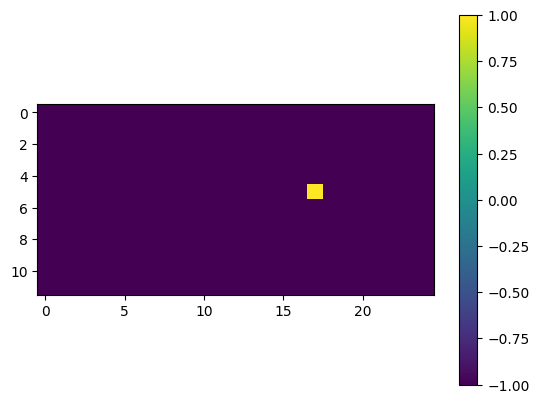

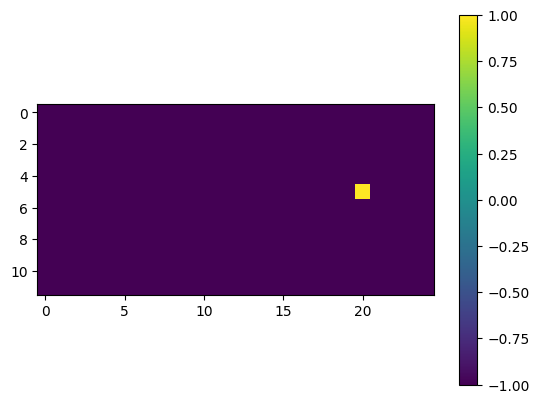

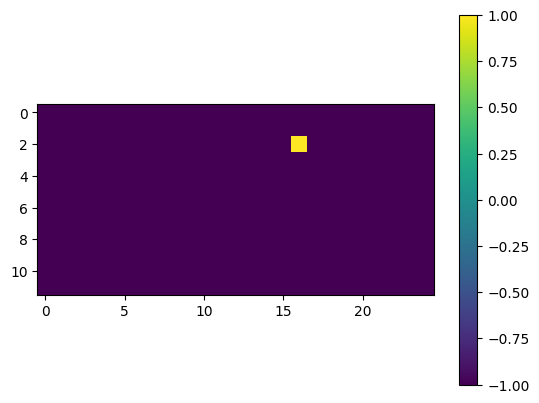

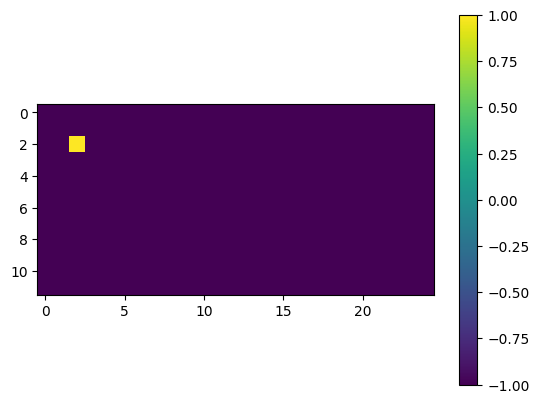

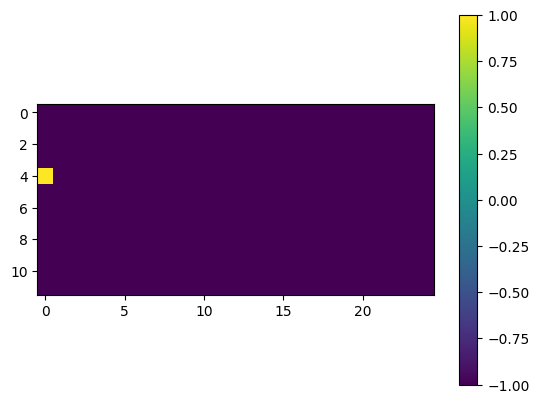

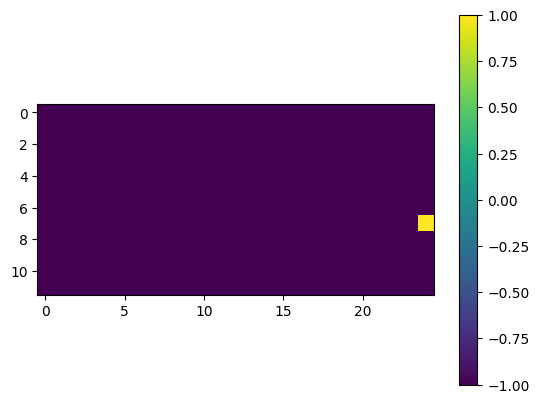

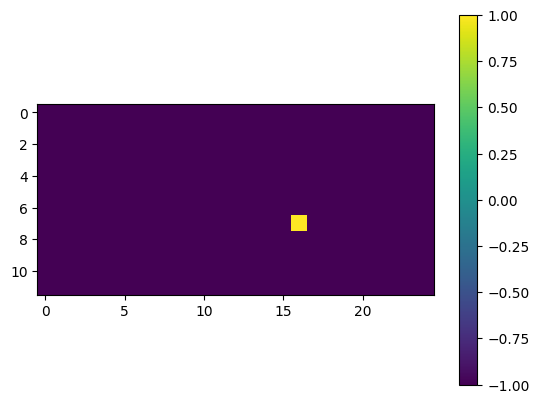

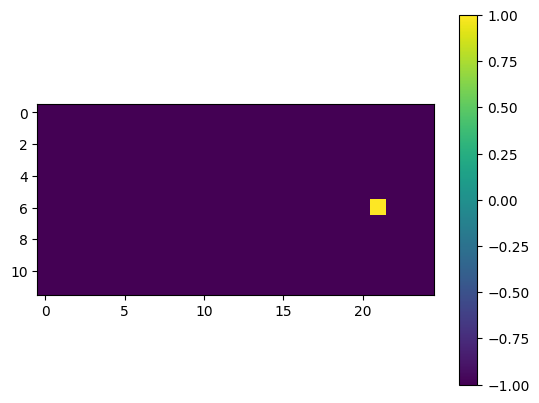

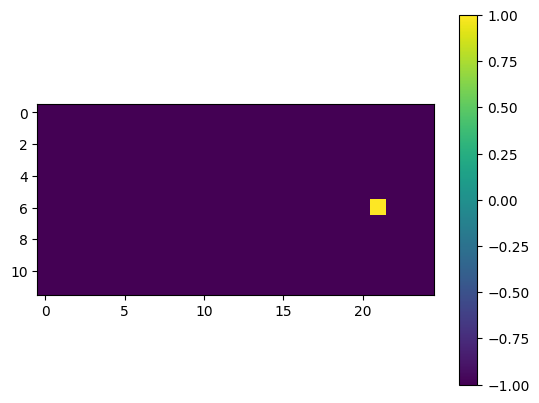

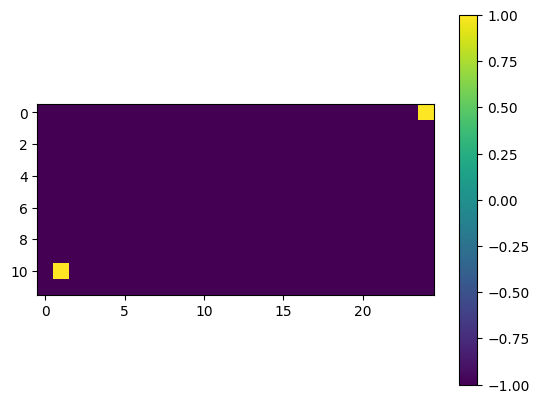

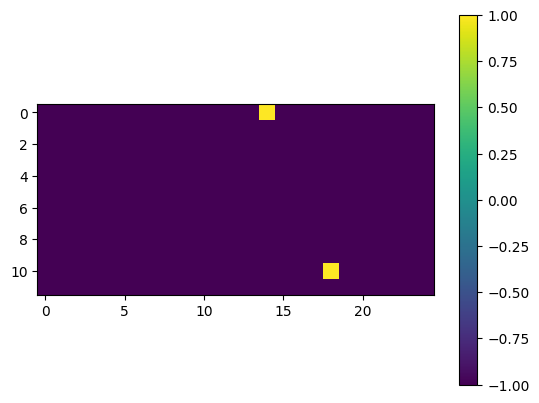

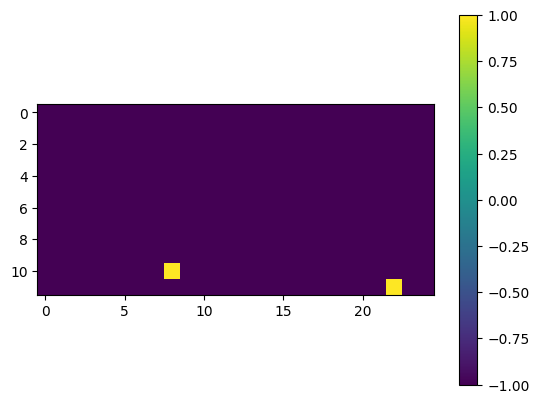

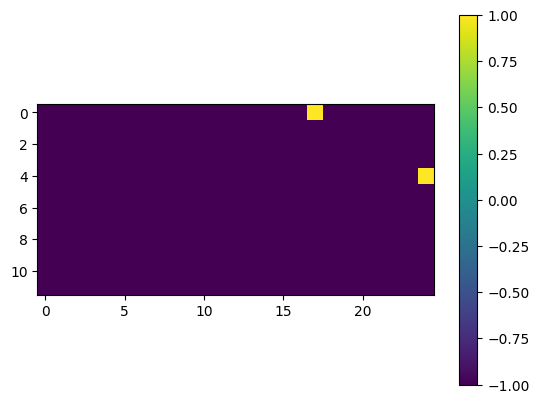

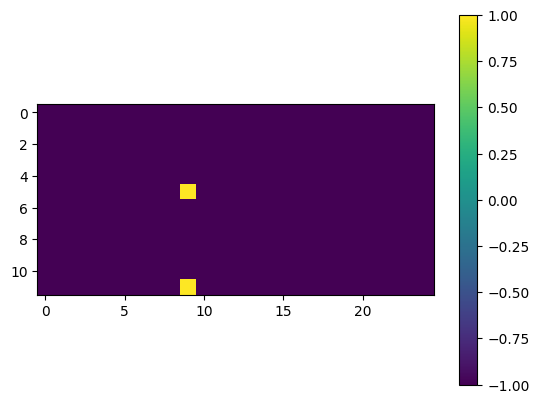

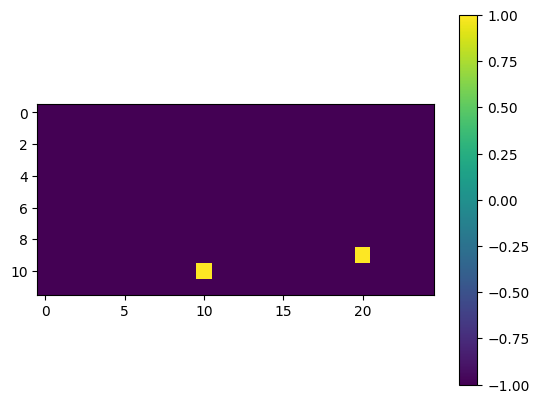

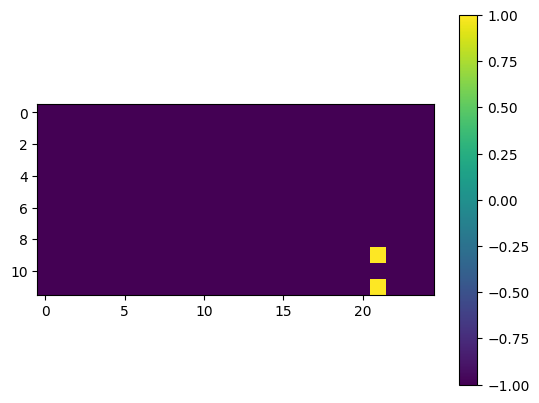

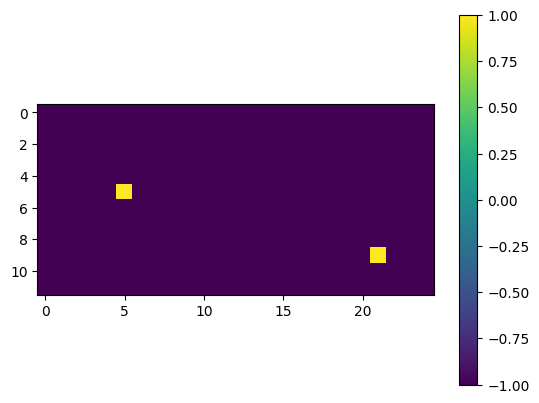

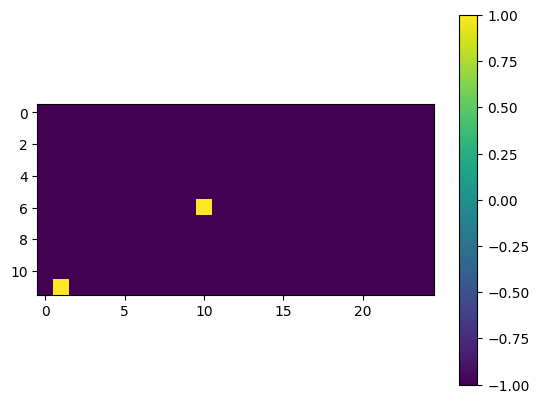

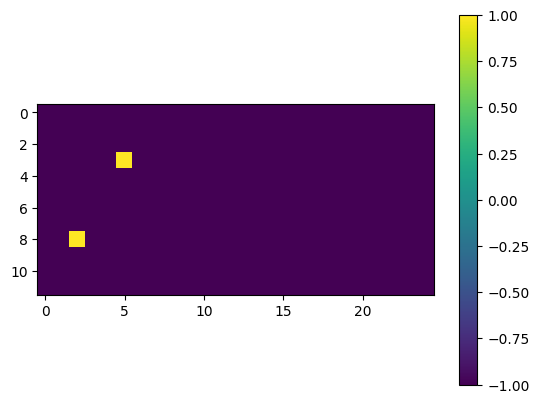

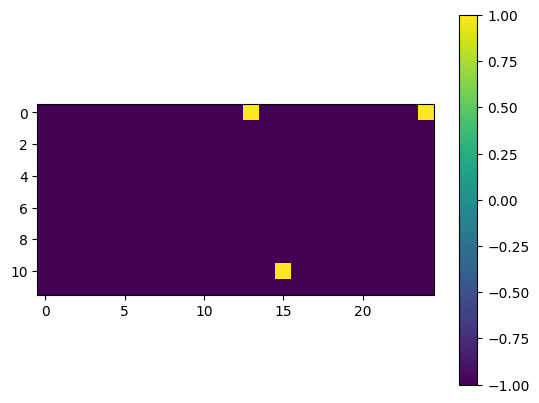

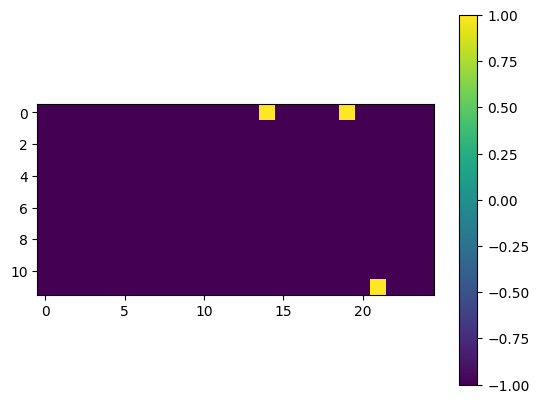

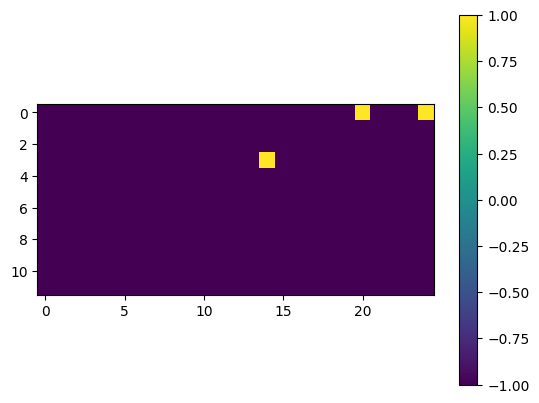

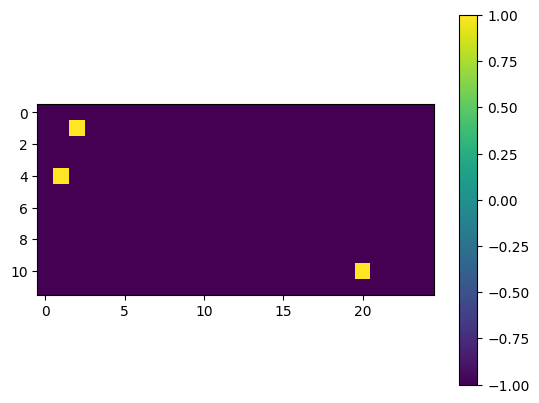

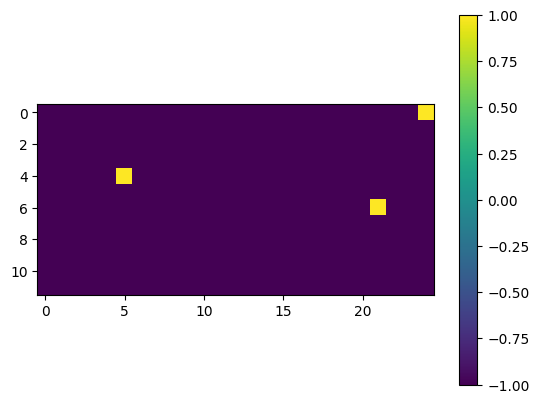

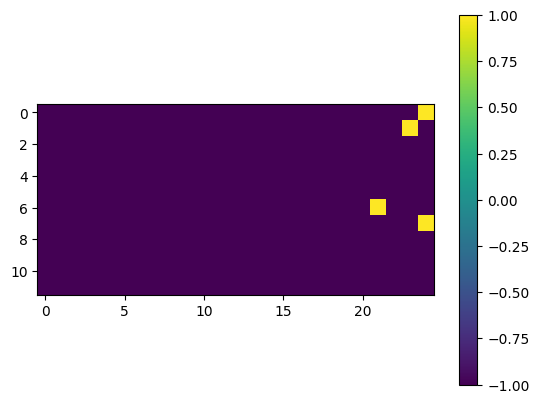

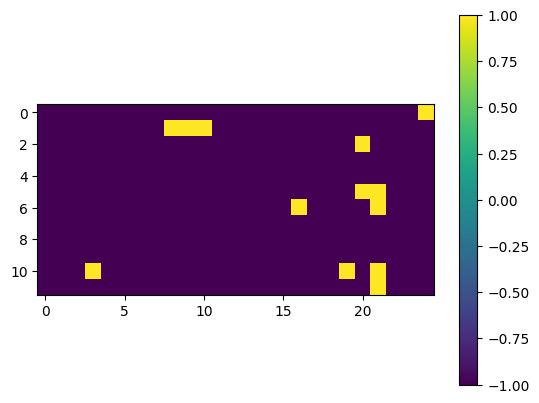

In [21]:
for sta in states:
    plt.figure()
    plt.imshow(sta)
    plt.colorbar()
    plt.show()
    plt.close()

In [ ]:
cm = 1 / 2.54
plt.figure(figsize=(15*cm, 7*cm))
plt.scatter(np.log(stats_sim['means'].flatten()), np.log(stats_exp['means'].flatten()), color='green', label='Means')
plt.scatter(np.log(np.ma.compressed(stats_sim['intra_corr'])), np.log(np.ma.compressed(stats_exp['intra_corr'])), color='blue', label='Intra')
plt.scatter(np.log(stats_sim['inter_corr'].flatten()), np.log(stats_exp['inter_corr'].flatten()), color='red', label='Inter')
plt.plot([-15, 1], [-15, 1], color='gray', ls='--')
plt.xlabel('QA Sampling')
plt.ylabel('Empirical Data')
plt.grid()
plt.gca().set_axisbelow(True)
#plt.xscale('log')
#plt.yscale('log')
#plt.xlim([1e-4, 1e0])
#plt.ylim([1e-4, 1e0])
plt.legend()
plt.subplots_adjust(left=0.15, right=0.95, top=0.9, bottom=0.2)
plt.savefig('param_corr_qa.pdf')

In [2]:

def load_exp_stats(marks_to_consider, L, suffix='_all'):
    m = list(marks_to_consider)
    M = len(m)
    return {
        'means': np.load(f'stats/means{suffix}.npy')[m],
        'intra_corr': np.ma.array(np.load(f'stats/intra_corr{suffix}.npy')[m, :][:, m], mask=np.triu(np.ones((M, M)), k=0)),
        'inter_corr': np.load(f'stats/inter_corr{suffix}.npy')[m, :L],
    }


def initialize_params_constant(M, L, c=0):
    return {
        'h': np.zeros(M),
        'J': np.ma.array(np.zeros((M, M)), mask=np.triu(np.ones((M, M)), k=0)),
        'K': np.zeros((M, L))
    }

def initialize_params_via_stats(stats):
    M = stats['intra_corr'].shape[0]
    return {
        'h': -stats['means'].copy(),
        'J': -np.ma.array(stats['intra_corr'].copy(), mask=np.triu(np.ones((M, M)), k=0)),
        'K': -stats['inter_corr'].copy()
    }


def get_state_energy(state, params):
    L = params['K'].shape[1]
    N = state.shape[1]
    E_h = np.sum(params['h'] * state.T)
    E_J = np.sum(params['J'] * np.sum(state.T[:, :, None] * state.T[:, None, :], axis=0))
    pre = [[(i + l) % N for i in range(N)] for l in range(1, L+1)]
    E_K = np.sum([np.sum(params['K'][:, l-1][:, np.newaxis] * state[:, pre[l-1]] * state[:, :]) for l in range(1, L+1)])
    return E_h + E_J + E_K


def initialize_state_constant(M, N, c=0):
    return np.zeros((M, N), dtype=np.uint8) + c

def initialize_state_random(M, N, p=None):
    state = np.empty((M, N), dtype=np.uint8)
    for m in range(M):
        state[m, :] = np.random.choice(a=[0, 1], size=N, p=(1-p[m], p[m]))
    return state


def print_state(state):
    print(''.join(['_' for _ in range(state.shape[1])]))
    for row in state:
        print(''.join(map(lambda x: '@' if x==1 else ' ', row)))
    print(''.join(['¯' for _ in range(state.shape[1])]))
    print('')

def get_state_means(state):
    return np.mean(state, axis=1)

def get_state_intra_corr(state):
    M = state.shape[0]
    c = np.zeros((M, M))
    for i in range(M):
        for j in range(i):
            c[i, j] = np.mean(state[i, :] * state[j, :])
    return np.ma.array(c, mask=np.triu(np.ones((M, M)), k=0))

def get_state_inter_corr(state, L):
    M = state.shape[0]
    tmp = np.empty((M, L), dtype=float)
    shift = [[(i + l) % N for i in range(N)] for l in range(1, L+1)]
    for i in range(M):
        for l in range(1, L+1):
            tmp[i, l-1] = np.mean(state[i, shift[l-1]] * state[i, :])
    return tmp

def get_inter_corr_for_states(states, L):
    M = states[0].shape[0]
    tmp = np.empty((M, L), dtype=float)
    shift = [[(i + l) % N for i in range(N)] for l in range(1, L+1)]
    for l in range(1, L+1):
        fence_right = np.concatenate([state[:, shift[l-1]] for state in states], axis=1)
        fence_left = np.concatenate([state[:, :] for state in states], axis=1)
        for i in range(M):
            tmp[i, l-1] = np.mean(fence_right[i] * fence_left[i])
    return tmp

def get_state_stats(state, L):
    return {
        'means': get_state_means(state),
        'intra_corr': get_state_intra_corr(state),
        'inter_corr': get_state_inter_corr(state, L),
    }

def get_stats_for_states(states, L):
    scarf = np.concatenate(states, axis=1)
    return {
        'means': get_state_means(scarf),
        'intra_corr': get_state_intra_corr(scarf),
        'inter_corr': get_inter_corr_for_states(states, L),
    }


def get_relative_error(stats_sim, stats_exp):
    e = 0
    e_means = np.sum(np.abs(stats_sim['means'] - stats_exp['means']))
    e_intra_corr = np.sum(np.abs(stats_sim['intra_corr'] - stats_exp['intra_corr']))
    e_inter_corr = np.sum(np.abs(stats_sim['inter_corr'] - stats_exp['inter_corr']))
    e = e_means + e_intra_corr + e_inter_corr
    exp_total = (np.sum(stats_exp['means']) + np.sum(stats_exp['intra_corr']) + np.sum(stats_exp['inter_corr']))
    if exp_total != 0:
        e /= exp_total
    else:
        e =0
    return e, (e_means / np.sum(stats_exp['means']), e_intra_corr / np.sum(stats_exp['intra_corr']), e_inter_corr / np.sum(stats_exp['inter_corr']))

def copy_numpy_dict(d):
    r = {}
    for i in d:
        r[i] = d[i].copy()
    return r


#def reduce_stats(statss):
#  r = {}
#  for key in ['means', 'intra_corr', 'inter_corr']:
#    r[key] = np.mean([stats[key] for stats in statss], axis=0)
#  return r


def do_mmc_iteration(state, params, beta, n_steps = 10_000):
    try:
        E_old = get_state_energy(state, params)
        r = np.random.rand(n_steps)
        M, N = state.shape
        for i in range(n_steps):
            m = np.random.randint(0, M)
            n = np.random.randint(0, N)
            ex = E_old
            state[m, n] = 1 - state[m, n]
            E_new = get_state_energy(state, params)
            E_diff = E_new - E_old
            if E_diff < 0 or np.exp(-E_diff * beta) > r[i]:
                E_old = E_new
            else:
                state[m, n] = 1 - state[m, n] # reverse
        return state
    
    except KeyboardInterrupt:
        return

def lsf(l):
    return '['+' '.join(["{:>7}".format(x) for x in np.round(l, 3)])+']'

def update_via_lr(params, stats_sim, stats_exp, lr):
    params['h'] += lr * (stats_sim['means'] - stats_exp['means'])
    params['J'] += lr * (stats_sim['intra_corr'] - stats_exp['intra_corr'])
    params['K'] += lr * (stats_sim['inter_corr'] - stats_exp['inter_corr'])

def update_via_lr_and_momentum(params, stats_sim, stats_exp, velocity, lr, momentum):
    params_prev = copy_numpy_dict(params)
    params['h'] = lr * (stats_sim['means'] - stats_exp['means']) + velocity['h']
    params['J'] = lr * (stats_sim['intra_corr'] - stats_exp['intra_corr']) + velocity['J']
    params['K'] = lr * (stats_sim['inter_corr'] - stats_exp['inter_corr']) + velocity['K']
    for key in ['h', 'J', 'K']:
        velocity[key] = params[key] + momentum * (params[key] - params_prev[key])